# ENSANUT Continua COVID-19 (2020) — Guanajuato
## Cuestionario de Salud de Adultos (20 años o más)
## Limpieza de Datos y Análisis Exploratorio (EDA)

> **Nota sobre este dataset:** A diferencia de las ediciones 2021 y 2022, esta encuesta fue levantada
> en el contexto de la pandemia de COVID-19 (2020). Su enfoque es distinto: no incluye diagnósticos
> de enfermedades crónicas ni escala de síntomas depresivos. En cambio, cubre:
> aceptación de vacunas (influenza y COVID-19), consumo de tabaco y alcohol,
> violencia e ideación suicida, y — de forma exclusiva para mujeres — episodios de
> violencia doméstica durante el período de confinamiento (23 de marzo al 1 de junio de 2020).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('future.no_silent_downcasting', True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

---
## 1. Carga de datos

In [2]:
df = pd.read_csv('../data/raw/2020/adultos_vac_tab_ensanut2020_w_gto.csv',
                 sep=';', low_memory=False)
df.shape

(1035, 114)

In [3]:
catalog = pd.read_excel('../data/raw/2020/adultos_vac_tab_ensanut2020_w_gto.Catlogo.xlsx',
                        sheet_name='Variables', skiprows=16)
print(catalog.columns.tolist())
catalog.head()

['Variable', 'Posición', 'Etiqueta', 'Nivel de medición', 'Ancho de columna']


,Variable,Posición,Etiqueta,Nivel de medición,Ancho de columna
0,FOLIO_I,1.0,Folio,Nominal,15.0
1,FOLIO_INT,2.0,Folio de integrante,Nominal,18.0
2,ID_INT,3.0,Integrante en el Hogar,Nominal,8.0
3,estrato,4.0,Estrato de Urbanidad según tamaño de la localidad,Nominal,10.0
4,region_cv,5.0,Regiones CV-19,Nominal,11.0


In [4]:
# Solo 2 etiquetas duplicadas en este catálogo — renombramos las únicas
label_counts = Counter(catalog['Etiqueta'].dropna().tolist())
col_mapping = {
    row['Variable']: row['Etiqueta']
    for _, row in catalog.iterrows()
    if pd.notna(row['Variable']) and pd.notna(row['Etiqueta'])
    and label_counts[row['Etiqueta']] == 1
}
df.rename(columns=col_mapping, inplace=True)
df_original = df.copy()
print(f'Columnas renombradas: {len(col_mapping)} | Con código original: {len(df.columns) - len(col_mapping)}')

Columnas renombradas: 105 | Con código original: 9


---
## 2. Limpieza de datos

### 2.1 Reemplazar espacios y strings vacíos por NaN

In [5]:
df = df.replace(' ', np.nan).replace('', np.nan)
print(f'Filas: {len(df)} | Columnas originales: {len(df.columns)}')

Filas: 1035 | Columnas originales: 114


### 2.2 Eliminar columnas con >70% de valores nulos

In [6]:
threshold = int(len(df) * 0.30)
df = df.dropna(thresh=threshold, axis=1)
print(f'Columnas eliminadas: {len(df_original.columns) - len(df.columns)} | Restantes: {len(df.columns)}')

Columnas eliminadas: 54 | Restantes: 60


### 2.3 Eliminar columnas con menos de 400 valores no nulos
> *Umbral ajustado a 400 (vs 800 en años previos) dado que n=1,035.*

In [7]:
cs = df.count()
to_drop = cs[cs < 400].index.tolist()
df = df.drop(columns=to_drop)
print(f'Columnas eliminadas: {len(to_drop)} | Restantes: {len(df.columns)}')

Columnas eliminadas: 1 | Restantes: 59


### 2.4 Eliminar columnas NOTA y constantes

In [8]:
nota = [c for c in df.columns if str(c).startswith('NOTA')]
df = df.drop(columns=nota)
nu = df.nunique(dropna=True)
constantes = nu[nu <= 1].index.tolist()
df = df.drop(columns=constantes)
print(f'NOTA eliminadas: {len(nota)} | Constantes: {len(constantes)}')

NOTA eliminadas: 4 | Constantes: 10


### 2.5 Eliminar columnas administrativas

In [9]:
admin_cols = [
    'Folio','Folio de integrante','Integrante en el Hogar','Maquina',
    'Hora de Inicio 1','Fecha de Inicio 1','Hora termino 1','Fecha termino 1',
    'Hora de Inicio 2','Fecha de Inicio 2','Hora de Termino 2','Fecha de Termino 2',
    'Hora de Inicio 3','Fecha de Inicio 3','Hora de Termino 3','Fecha de Termino 3',
    'Hora de Inicio 4','Fecha de Inicio 4','Hora de Termino 4','Fecha de Termino 4',
    'Hora de Inicio','Fecha de inicio','Hora de termino','Fecha de Termino',
    'Duración de la Entrevista 1','Resultado de entrevista 1',
    'Duración de la Entrevista 2','Resultado de entrevista 2',
    'Duración de la Entrevista 3','Resultado de entrevista 3',
    'Duración de la Entrevista 4','Resultado de entrevista 4',
    'Duración de la Entrevista','Resultado de Entrevista',
    'Concentimiento para realizar la entrevista','Regiones CV-19',
    'Entidad','DESC_ENT','Fecha de Nacimiento','localizado',
    '¿Algún comentario de la entrevista?','Especifique otro resultado de entrevista',
    'Entrevista de Adulto Completa','ADULTOS',
]
admin_cols = [c for c in admin_cols if c in df.columns]
df = df.drop(columns=admin_cols)
print(f'Administrativas eliminadas: {len(admin_cols)} | Restantes: {len(df.columns)}')

Administrativas eliminadas: 20 | Restantes: 25


### 2.6 Corregir tipos de datos

In [10]:
obj_cols = df.select_dtypes(include='object').columns.tolist()
converted = []
for col in obj_cols:
    series = df[col]
    if isinstance(series, pd.DataFrame): continue
    nv = series.notna().sum()
    if nv == 0: continue
    conv = pd.to_numeric(series, errors='coerce')
    if conv.notna().sum() / nv > 0.7:
        df[col] = conv
        converted.append(col)

# Ponderadores con coma decimal
for col_pond in ['Ponderador', 'ponderador actualizado a Censo 2020']:
    if col_pond in df.columns:
        df[col_pond] = pd.to_numeric(
            df[col_pond].astype(str).str.replace(',', '.', regex=False), errors='coerce')

print(f'Convertidas a numérico: {len(converted)}')
print(f'Tipos finales: {df.dtypes.value_counts().to_dict()}')

Convertidas a numérico: 9
Tipos finales: {dtype('int64'): 13, dtype('float64'): 11, dtype('O'): 1}


### 2.7 Verificar duplicados

In [11]:
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Shape: {df.shape}')

Filas duplicadas: 0
Shape: (1035, 25)


### 2.8 Revisar nulos restantes

In [12]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(f'Columnas con nulos: {len(null_pct)}')
print()
print(null_pct.round(1).to_string())

Columnas con nulos: 9

ADUL301D 3.1d Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Agresión económica?                        41.0
ADUL301A 3.1a Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Gritos, insultos o amenazas?               41.0
ADUL301B 3.1b Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Empujones, jalones o golpes?               41.0
ADUL301C 3.1c Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Actos de carácter sexual o violaciones?    41.0
ADUL102 2. Aceptaría aplicarse la vacuna de la influenza en los próximos meses (octubre-diciembre 2020)?                                                         

### 2.9 Análisis e imputación de valores nulos

#### Variables 1–4/5 — Violencia durante el confinamiento (solo mujeres)

In [13]:
col_301a = 'ADUL301A 3.1a Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Gritos, insultos o amenazas?'
confinamiento_cols = [c for c in df.columns if 'ADUL301' in c]

print(f'Columnas de violencia en confinamiento: {len(confinamiento_cols)}')
print(f'Nulos por columna: {df[confinamiento_cols].isnull().sum().to_dict()}')
print()
print('Nulos × Sexo (1=Hombre, 2=Mujer):')
print(df.loc[df[col_301a].isna(), 'Sexo'].value_counts().to_dict())
print()
print(f'Total hombres: {(df["Sexo"]==1).sum()} | Total mujeres: {(df["Sexo"]==2).sum()}')

Columnas de violencia en confinamiento: 4
Nulos por columna: {'ADUL301A 3.1a Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Gritos, insultos o amenazas?': 424, 'ADUL301B 3.1b Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Empujones, jalones o golpes?': 424, 'ADUL301C 3.1c Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Actos de carácter sexual o violaciones?': 424, 'ADUL301D 3.1d Durante el período de confinamiento (23 de marzo al 1 de junio) ¿Vivió hechos de violencia o agresiones por algún integrante de su hogar como Agresión económica?': 424}

Nulos × Sexo (1=Hombre, 2=Mujer):
{1: 424}

Total hombres: 424 | Total mujeres: 611


In [14]:
# ── Análisis ──────────────────────────────────────────────────────────────
# Los 424 nulos corresponden EXACTAMENTE a los 424 hombres del dataset.
# La sección 3 ("Violencia durante el confinamiento") fue aplicada
# ÚNICAMENTE a mujeres de 20 años o más, por diseño de la encuesta.
# Son nulos ESTRUCTURALES — los hombres no fueron expuestos a estas preguntas.
#
# Estrategia: asignar valor 0 = "No aplica (hombre)" en lugar de 2 (No),
# para distinguir claramente entre "no vivió violencia" y "no se le preguntó".

for col in confinamiento_cols:
    df[col] = df[col].fillna(0)
    
print('Distribución tras imputación (ADUL301A):')
label_conf = {0:'No aplica\n(hombre)', 1:'Sí', 2:'No', 9:'No sabe'}
print(df[col_301a].map(label_conf).value_counts().to_dict())
print(f'Nulos restantes: {df[confinamiento_cols].isnull().sum().sum()}')

Distribución tras imputación (ADUL301A):
{'No': 587, 'No aplica\n(hombre)': 424, 'Sí': 21, 'No sabe': 3}
Nulos restantes: 0


#### Variable 5a–5c/5 — Vacunas sección 20–59 años (ADUL101, 102, 103)

In [15]:
vac_cols = {
    'Vacuna influenza (aplicada)':    'ADUL101 1. A partir de septiembre del año pasado y hasta el día de hoy, ¿le han aplicado la vacuna contra la Influenza?',
    'Aceptaría vacuna influenza':     'ADUL102 2. Aceptaría aplicarse la vacuna de la influenza en los próximos meses (octubre-diciembre 2020)?',
    'Aceptaría vacuna COVID-19':      'ADUL103 3.  Aceptaría aplicarse la vacuna contra COVID en el momento en el que esté disponible?',
}
vac_cols = {k:v for k,v in vac_cols.items() if v in df.columns}

col_vac1 = list(vac_cols.values())[0]
print(f'Nulos: {df[col_vac1].isna().sum()}')
print('Edad de filas con nulos:')
print(df.loc[df[col_vac1].isna(), 'Edad'].describe())

Nulos: 248
Edad de filas con nulos:
count    248.000000
mean      71.221774
std        8.418892
min       60.000000
25%       64.750000
50%       69.000000
75%       76.000000
max       97.000000
Name: Edad, dtype: float64


In [16]:
# ── Análisis ──────────────────────────────────────────────────────────────
# Los 248 nulos son EXCLUSIVAMENTE personas de 60+ años (mín=60, máx=97).
# La encuesta tiene dos secciones de vacunas: ADUL101-103 para adultos 20-59
# y ADUL104-108 para adultos 60+ (esta segunda sección fue descartada por
# tener <400 respuestas en el filtro de limpieza).
# Los nulos son ESTRUCTURALES por lógica de edad.
#
# Estrategia: imputar con moda de cada columna. Los adultos mayores no
# tienen registrada su respuesta equivalente en el dataset final.

for label, col in vac_cols.items():
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f'{label}: imputado con moda={moda} | nulos: {df[col].isna().sum()}')

Vacuna influenza (aplicada): imputado con moda=2.0 | nulos: 0
Aceptaría vacuna influenza: imputado con moda=1.0 | nulos: 0
Aceptaría vacuna COVID-19: imputado con moda=1.0 | nulos: 0


#### Variable 5d/5 — Tabaco en el pasado (ADUL1a04a)

In [17]:
col_past = 'ADUL1a04a En el pasado ¿Has fumado productos de tabaco...'
col_curr = 'ADUL1a01 Actualmente fuma tabaco...'
if col_past in df.columns:
    print('Distribución actual (ADUL1a01):', df[col_curr].value_counts().to_dict())
    print('Nulos en pasado × actual:', df.loc[df[col_past].isna(), col_curr].value_counts().to_dict())

Distribución actual (ADUL1a01): {3: 872, 1: 83, 2: 77, 9: 3}
Nulos en pasado × actual: {1: 83, 2: 77, 9: 3}


In [18]:
# ── Análisis ──────────────────────────────────────────────────────────────
# Idéntico al patrón de 2021 y 2022: los 163 nulos son fumadores actuales
# (ADUL1a01 = 1 o 2). Skip logic por diseño.
# Estrategia: categoría 0 = "Actualmente fuma".

if col_past in df.columns:
    df[col_past] = df[col_past].fillna(0)
    label_map = {0:'Actualmente fuma',1:'Fumaba (diario)',2:'Fumaba (ocas.)',3:'Nunca fumó',9:'No sabe'}
    print('Distribución final:', df[col_past].map(label_map).value_counts().to_dict())
    print(f'Nulos restantes: {df[col_past].isna().sum()}')

Distribución final: {'Nunca fumó': 726, 'Actualmente fuma': 163, 'Fumaba (ocas.)': 100, 'Fumaba (diario)': 44, 'No sabe': 2}
Nulos restantes: 0


#### Variable 5e/5 — Unidad Primaria de Muestreo

In [19]:
# UPM: variable administrativa → eliminar (mismo criterio que 2021 y 2022)
if 'Unidad Primaria de Muestreo' in df.columns:
    df = df.drop(columns=['Unidad Primaria de Muestreo'])
    print("'Unidad Primaria de Muestreo' eliminada.")
print(f'Shape: {df.shape}')

'Unidad Primaria de Muestreo' eliminada.
Shape: (1035, 24)


#### Verificación final

In [20]:
total_nulos = df.isnull().sum().sum()
print(f'Total valores nulos: {total_nulos}')
print(f'Shape final: {df.shape}')
if total_nulos == 0:
    print('\n✓ El dataset está completamente limpio — sin valores nulos.')
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total valores nulos: 0
Shape final: (1035, 24)

✓ El dataset está completamente limpio — sin valores nulos.


### 2.10 Crear variables derivadas

In [21]:
# Grupos etarios
bins   = [20, 30, 40, 50, 60, 70, 80, 100]
labels = ['20-29','30-39','40-49','50-59','60-69','70-79','80+']
df['Grupo etario'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=False)

# Sexo como etiqueta
df['Sexo_lbl'] = df['Sexo'].map({1:'Hombre', 2:'Mujer'})

# Urbanidad
df['Urbanidad'] = df['Estrato de Urbanidad según tamaño de la localidad'].map(
    {1:'Rural', 2:'Semi-urbano', 3:'Urbano'})

# Municipio limpio
if 'DESC_MUN' in df.columns:
    df['Municipio'] = df['DESC_MUN'].str.replace(r'^\d+\s+', '', regex=True)

# Índice de violencia confinamiento (solo mujeres — score 0-4)
conf_cols = [c for c in df.columns if 'ADUL301' in c]
if conf_cols:
    mujeres_mask = df['Sexo'] == 2
    df.loc[mujeres_mask, 'Score violencia confinamiento'] = (
        df.loc[mujeres_mask, conf_cols].apply(lambda row: (row == 1).sum(), axis=1))

print(f'Dataset listo: {df.shape}')

Dataset listo: (1035, 28)


### 2.11 Resumen del dataset limpio

In [22]:
display(df.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']])

,count,unique,top,freq,mean,std,min,max
Estrato de Urbanidad según tamaño de la localidad,1035.0,NaN,NaN,NaN,2.08599,0.84216,1.0,3.0
Estrato de selección,1035.0,NaN,NaN,NaN,112.08599,0.84216,111.0,113.0
Municipio,1035,17,LEÓN,354,NaN,NaN,NaN,NaN
DESC_MUN,1035,17,020 LEÓN,354,NaN,NaN,NaN,NaN
Sexo,1035.0,NaN,NaN,NaN,1.590338,0.492009,1.0,2.0
Edad,1035.0,NaN,NaN,NaN,45.806763,17.851671,20.0,97.0
Meses adicionales en relacion a la fecha de cumpleaños,1035.0,NaN,NaN,NaN,5.175845,3.395012,0.0,11.0
"ADUL101 1. A partir de septiembre del año pasado y hasta el día de hoy, ¿le han aplicado la vacuna contra la Influenza?",1035.0,NaN,NaN,NaN,1.73913,0.888115,1.0,9.0
ADUL102 2. Aceptaría aplicarse la vacuna de la influenza en los próximos meses (octubre-diciembre 2020)?,1035.0,NaN,NaN,NaN,1.448309,1.387978,1.0,9.0
ADUL103 3. Aceptaría aplicarse la vacuna contra COVID en el momento en el que esté disponible?,1035.0,NaN,NaN,NaN,2.10628,2.482883,1.0,9.0


In [23]:
clean_path = '../data/processed/ensanut2020_GTO_clean.csv'
df.to_csv(clean_path, index=False, encoding='utf-8-sig')
print(f'Dataset limpio exportado → {clean_path}')
print(f'Shape: {df.shape}')

Dataset limpio exportado → ../data/processed/ensanut2020_GTO_clean.csv
Shape: (1035, 28)


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Demografía general

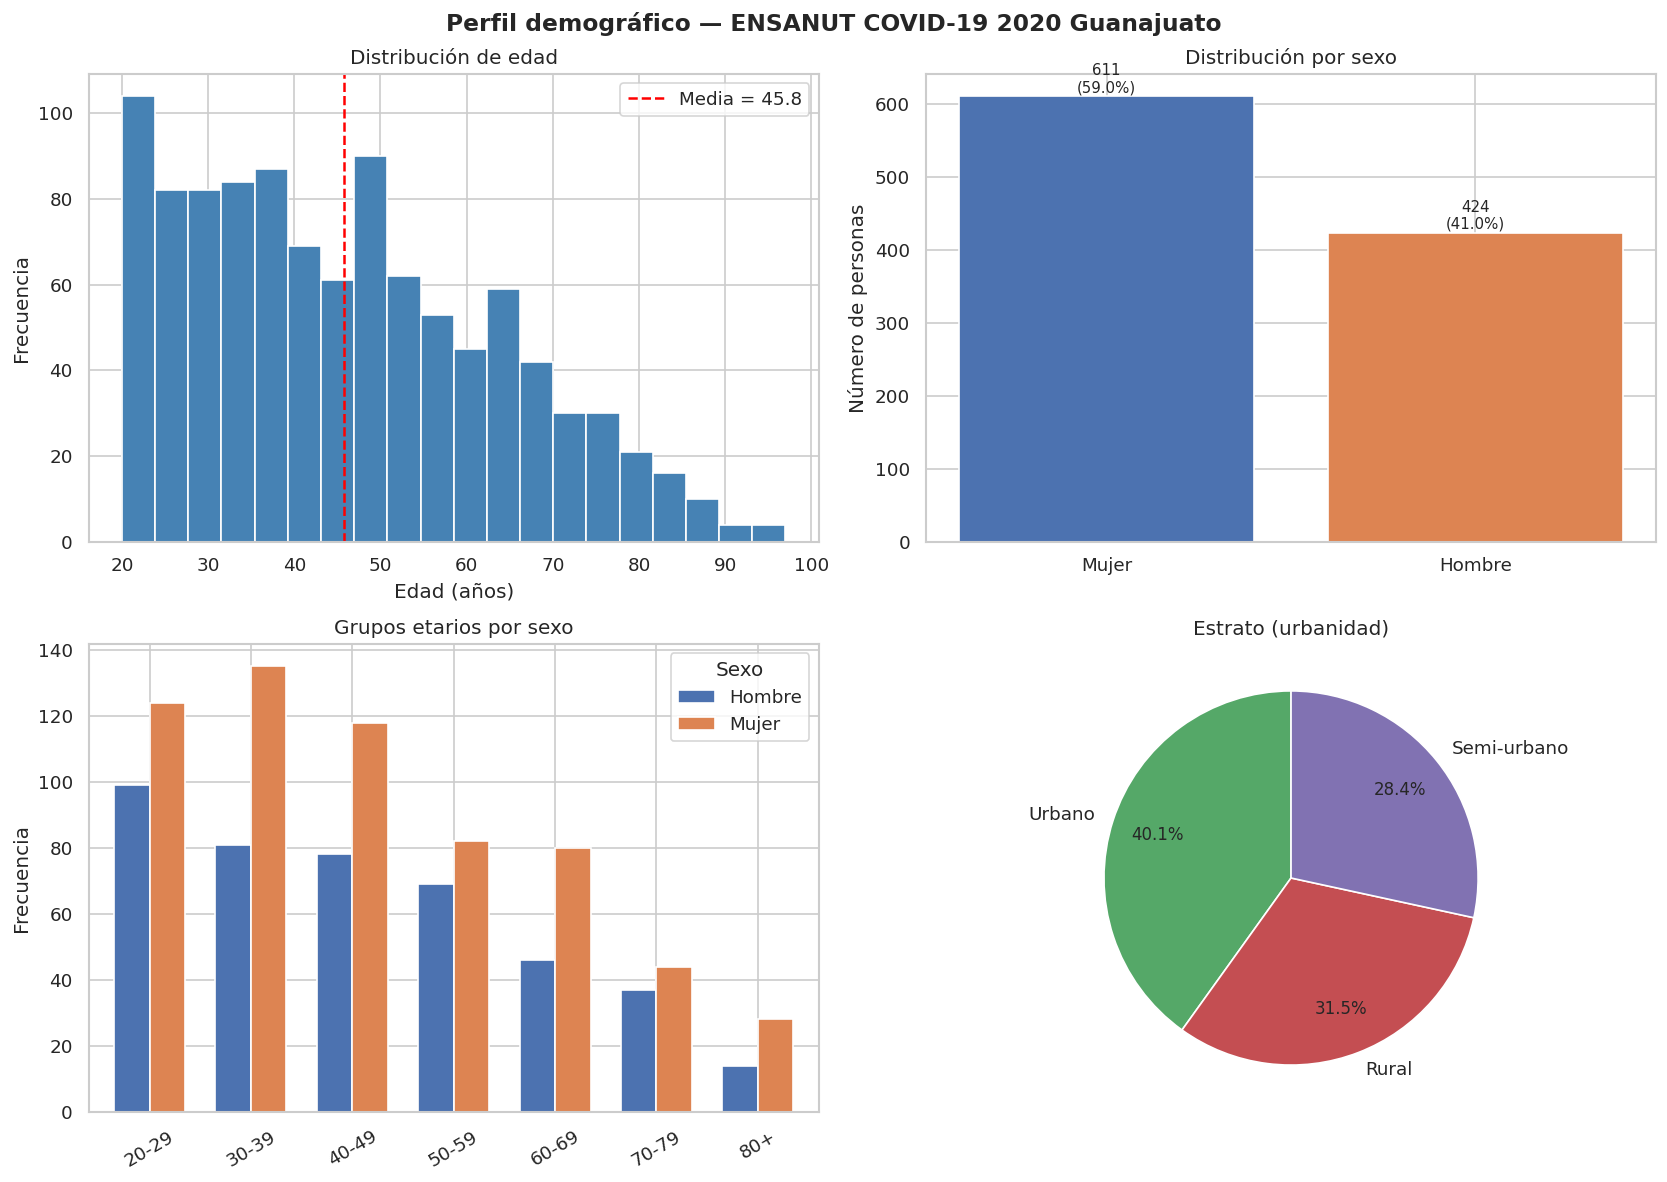

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perfil demográfico — ENSANUT COVID-19 2020 Guanajuato', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.hist(df['Edad'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_title('Distribución de edad'); ax.set_xlabel('Edad (años)'); ax.set_ylabel('Frecuencia')
ax.axvline(df['Edad'].mean(), color='red', linestyle='--',
           label=f'Media = {df["Edad"].mean():.1f}')
ax.legend()

ax = axes[0,1]
sex_counts = df['Sexo_lbl'].value_counts()
bars = ax.bar(sex_counts.index, sex_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white')
ax.set_title('Distribución por sexo'); ax.set_ylabel('Número de personas')
for bar, val in zip(bars, sex_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

ax = axes[1,0]
cross = df.groupby(['Grupo etario','Sexo_lbl'], observed=True).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.7)
ax.set_title('Grupos etarios por sexo'); ax.set_xlabel(''); ax.set_ylabel('Frecuencia')
ax.legend(title='Sexo'); ax.tick_params(axis='x', rotation=30)

ax = axes[1,1]
urb = df['Urbanidad'].value_counts()
ax.pie(urb.values, labels=urb.index, autopct='%1.1f%%',
       colors=['#55A868','#C44E52','#8172B2'], startangle=90, pctdistance=0.75)
ax.set_title('Estrato (urbanidad)')

plt.tight_layout()
plt.savefig('../outputs/figures/2020/eda_demografia.png', bbox_inches='tight')
plt.show()

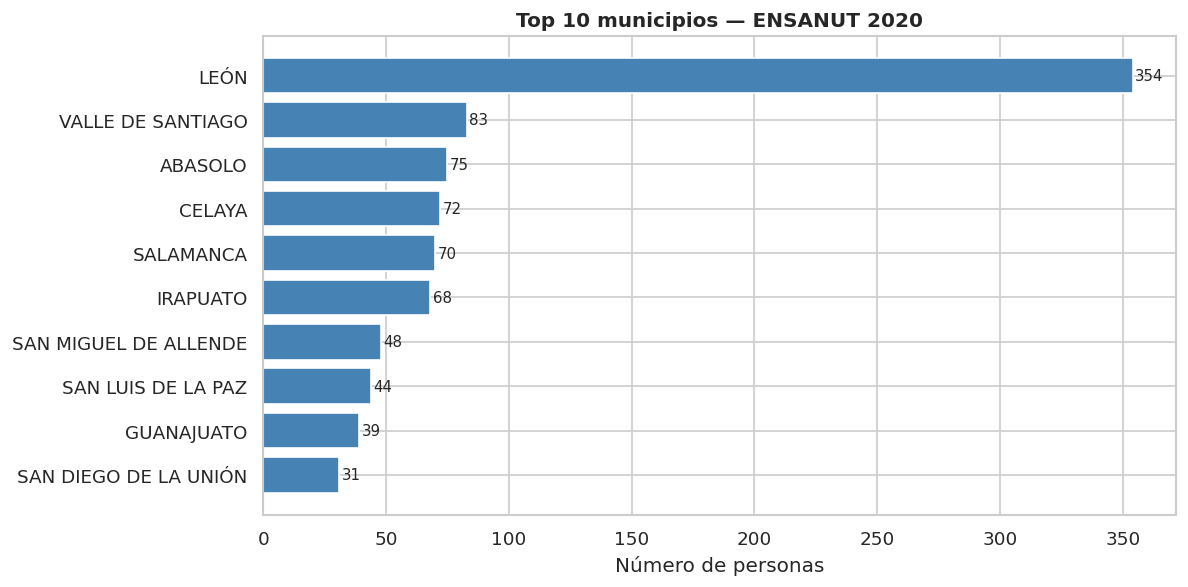

In [25]:
if 'Municipio' in df.columns:
    mun_top = df['Municipio'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10,5))
    bars = ax.barh(mun_top.index[::-1], mun_top.values[::-1], color='steelblue', edgecolor='white')
    ax.set_title('Top 10 municipios — ENSANUT 2020', fontweight='bold')
    ax.set_xlabel('Número de personas')
    for bar, val in zip(bars, mun_top.values[::-1]):
        ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../outputs/figures/2020/eda_municipios.png', bbox_inches='tight')
    plt.show()

### 3.2 Aceptación de vacunas

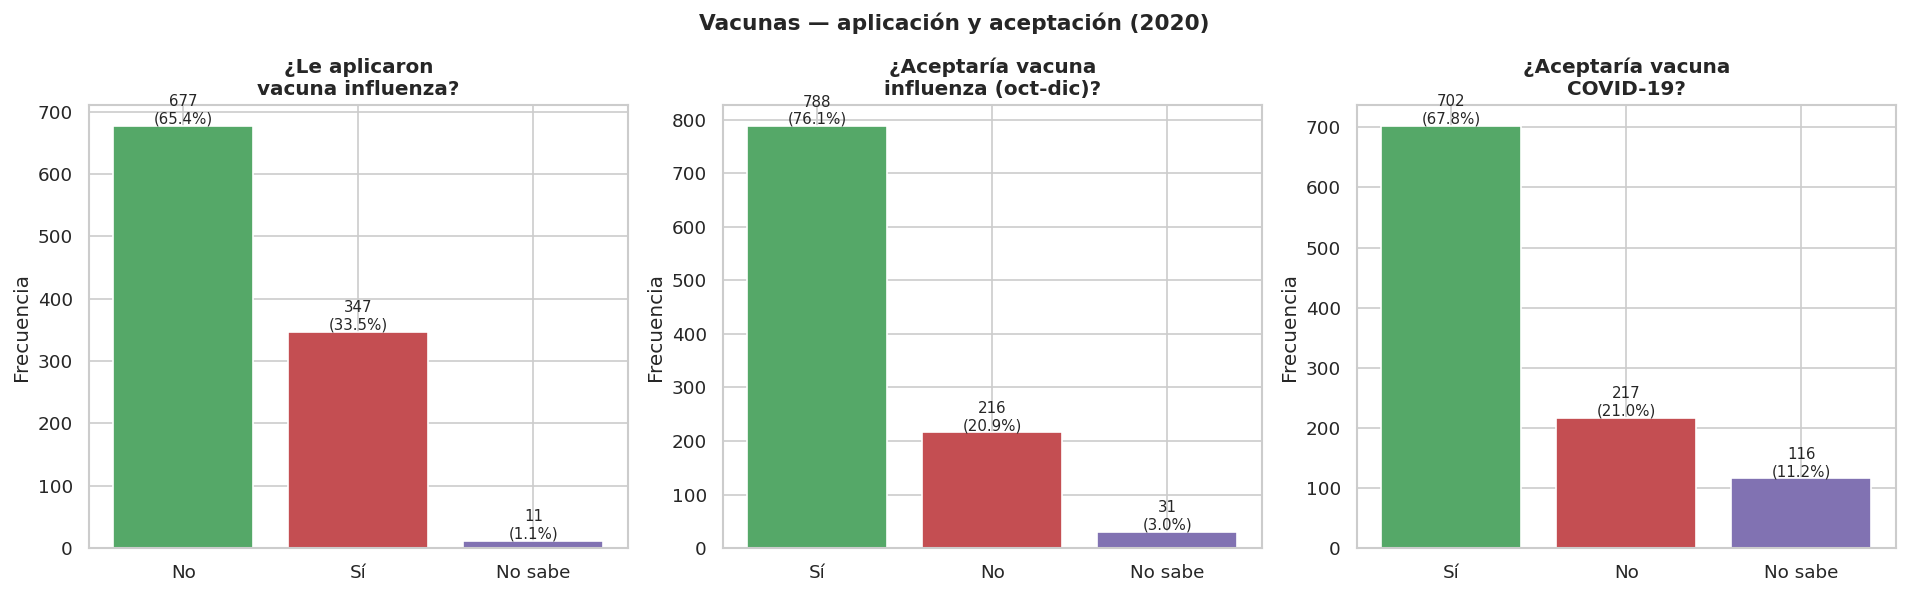

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vacunas — aplicación y aceptación (2020)', fontsize=13, fontweight='bold')

vac_plot = {
    '¿Le aplicaron\nvacuna influenza?': (
        'ADUL101 1. A partir de septiembre del año pasado y hasta el día de hoy, ¿le han aplicado la vacuna contra la Influenza?',
        {1:'Sí',2:'No',9:'No sabe'}),
    '¿Aceptaría vacuna\ninfluenza (oct-dic)?': (
        'ADUL102 2. Aceptaría aplicarse la vacuna de la influenza en los próximos meses (octubre-diciembre 2020)?',
        {1:'Sí',2:'No',9:'No sabe'}),
    '¿Aceptaría vacuna\nCOVID-19?': (
        'ADUL103 3.  Aceptaría aplicarse la vacuna contra COVID en el momento en el que esté disponible?',
        {1:'Sí',2:'No',9:'No sabe'}),
}

colors_vac = ['#55A868','#C44E52','#8172B2']
for ax, (title, (col, lmap)) in zip(axes, vac_plot.items()):
    if col not in df.columns: continue
    counts = df[col].map(lmap).value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors_vac[:len(counts)], edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2020/eda_vacunas.png', bbox_inches='tight')
plt.show()

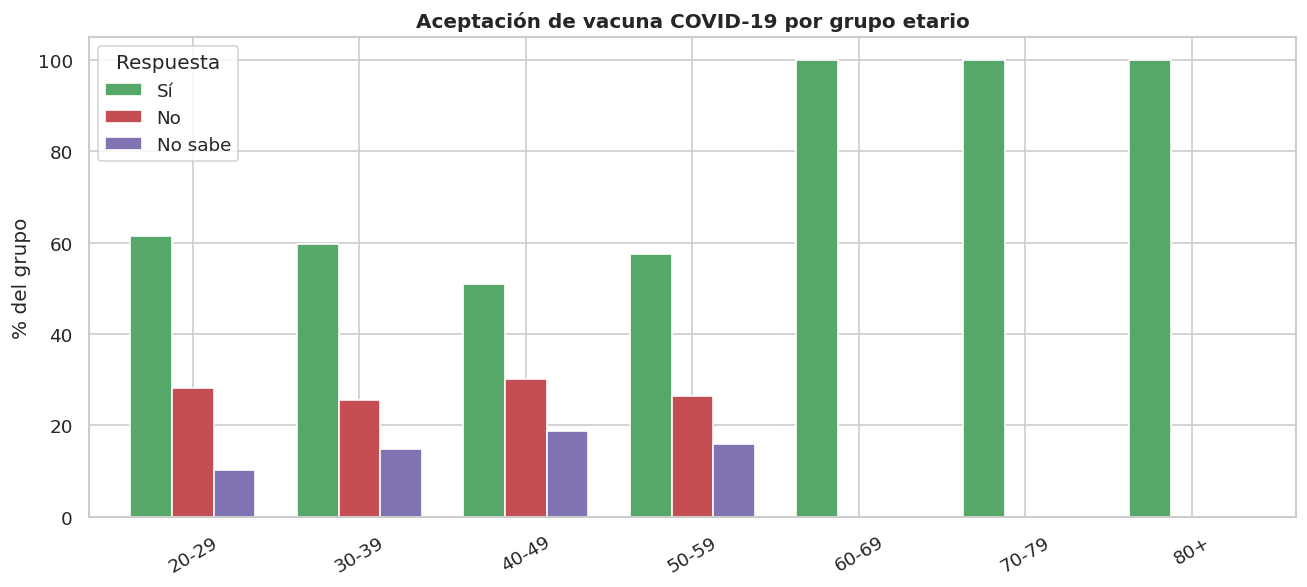

In [27]:
# Aceptación de vacuna COVID-19 por grupo etario y sexo
col_covid = 'ADUL103 3.  Aceptaría aplicarse la vacuna contra COVID en el momento en el que esté disponible?'
if col_covid in df.columns:
    df['Acepta COVID vac'] = df[col_covid].map({1:'Sí',2:'No',9:'No sabe'})
    pivot = df.groupby(['Grupo etario','Acepta COVID vac'], observed=True).size().unstack(fill_value=0)
    pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(11,5))
    pct[['Sí','No','No sabe']].plot(kind='bar', ax=ax,
        color=['#55A868','#C44E52','#8172B2'], edgecolor='white', width=0.75)
    ax.set_title('Aceptación de vacuna COVID-19 por grupo etario', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('% del grupo'); ax.legend(title='Respuesta')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('../outputs/figures/2020/eda_vacuna_covid_edad.png', bbox_inches='tight')
    plt.show()

### 3.3 Tabaco y alcohol

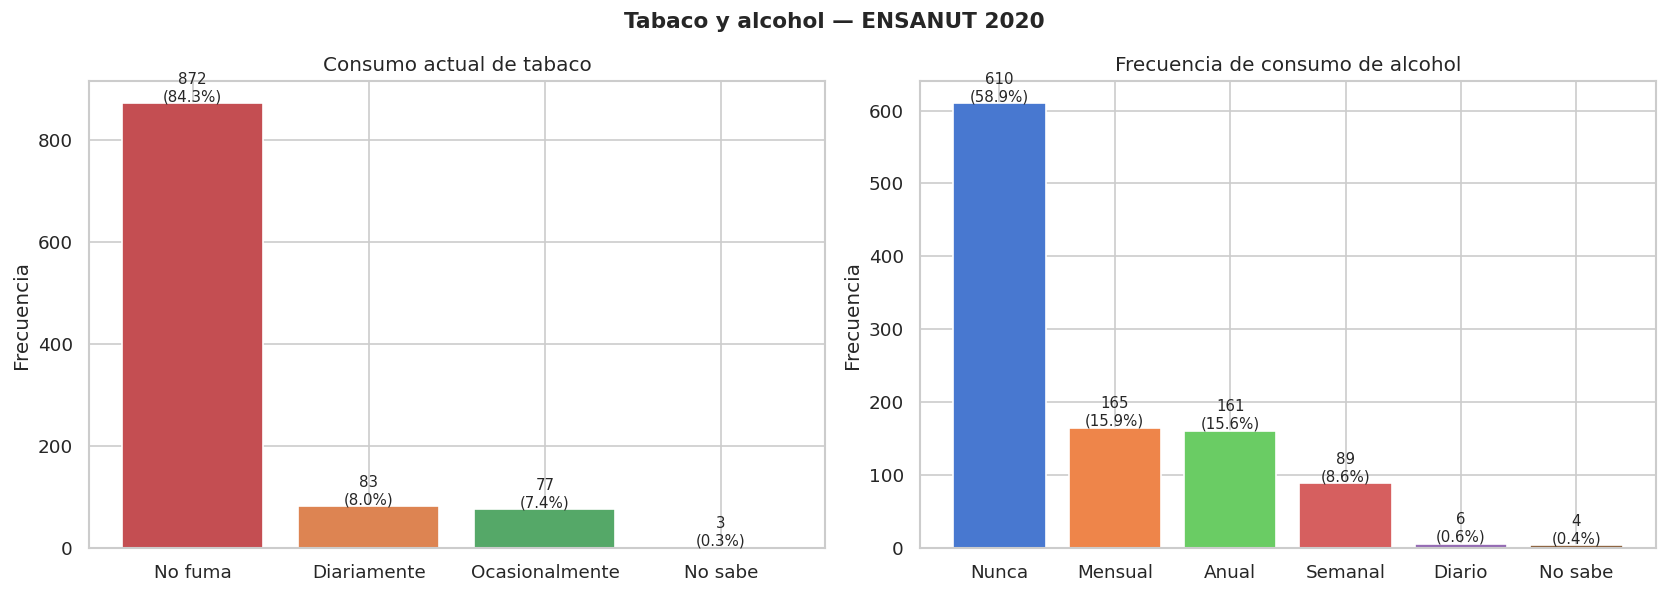

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tabaco y alcohol — ENSANUT 2020', fontsize=13, fontweight='bold')

col_tab = 'ADUL1a01 Actualmente fuma tabaco...'
if col_tab in df.columns:
    ax = axes[0]
    tab_map = {1:'Diariamente',2:'Ocasionalmente',3:'No fuma',9:'No sabe'}
    counts = df[col_tab].map(tab_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#C44E52','#DD8452','#55A868','#8172B2'], edgecolor='white')
    ax.set_title('Consumo actual de tabaco'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

col_alc = 'ADUL1a06 Piensa en tu consumo de alcohol, ¿con qué frecuencia tomas una copa de ya sea vino, cerveza, whisky o cualquier otra bebida que contenga alcohol?'
if col_alc in df.columns:
    ax = axes[1]
    alc_map = {1:'Diario',2:'Semanal',3:'Mensual',4:'Anual',5:'Nunca',6:'Dejó de beber',9:'No sabe'}
    counts = df[col_alc].map(alc_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(counts)), edgecolor='white')
    ax.set_title('Frecuencia de consumo de alcohol'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2020/eda_tabaco_alcohol.png', bbox_inches='tight')
plt.show()

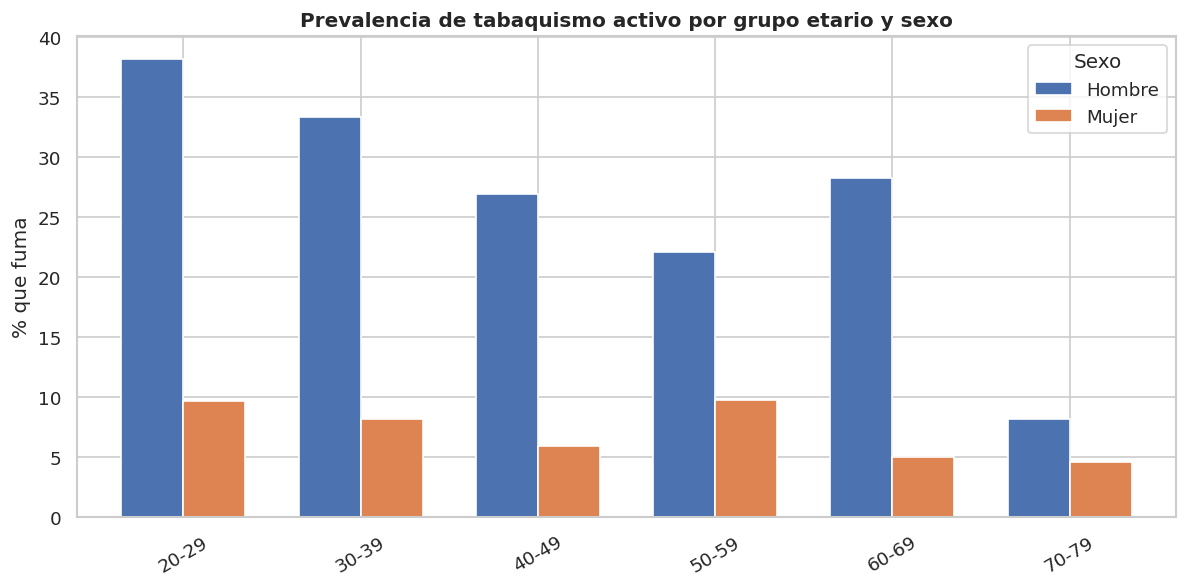

In [29]:
# Tabaco por sexo y grupo etario
col_tab = 'ADUL1a01 Actualmente fuma tabaco...'
if col_tab in df.columns:
    df['Fuma'] = df[col_tab].map({1:'Fuma',2:'Fuma',3:'No fuma',9:'No sabe'})
    pivot_tab = (df[df['Fuma']!='No sabe']
                 .groupby(['Grupo etario','Sexo_lbl','Fuma'], observed=True)
                 .size().reset_index(name='n'))
    pivot_tab['pct'] = pivot_tab.groupby(['Grupo etario','Sexo_lbl'], observed=True)['n'].transform(
        lambda x: x/x.sum()*100)
    fuma_pct = pivot_tab[pivot_tab['Fuma']=='Fuma'].pivot_table(
        index='Grupo etario', columns='Sexo_lbl', values='pct', observed=True)

    fig, ax = plt.subplots(figsize=(10,5))
    fuma_pct.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.7)
    ax.set_title('Prevalencia de tabaquismo activo por grupo etario y sexo', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('% que fuma'); ax.legend(title='Sexo')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('../outputs/figures/2020/eda_tabaco_edad_sexo.png', bbox_inches='tight')
    plt.show()

### 3.4 Violencia e ideación suicida

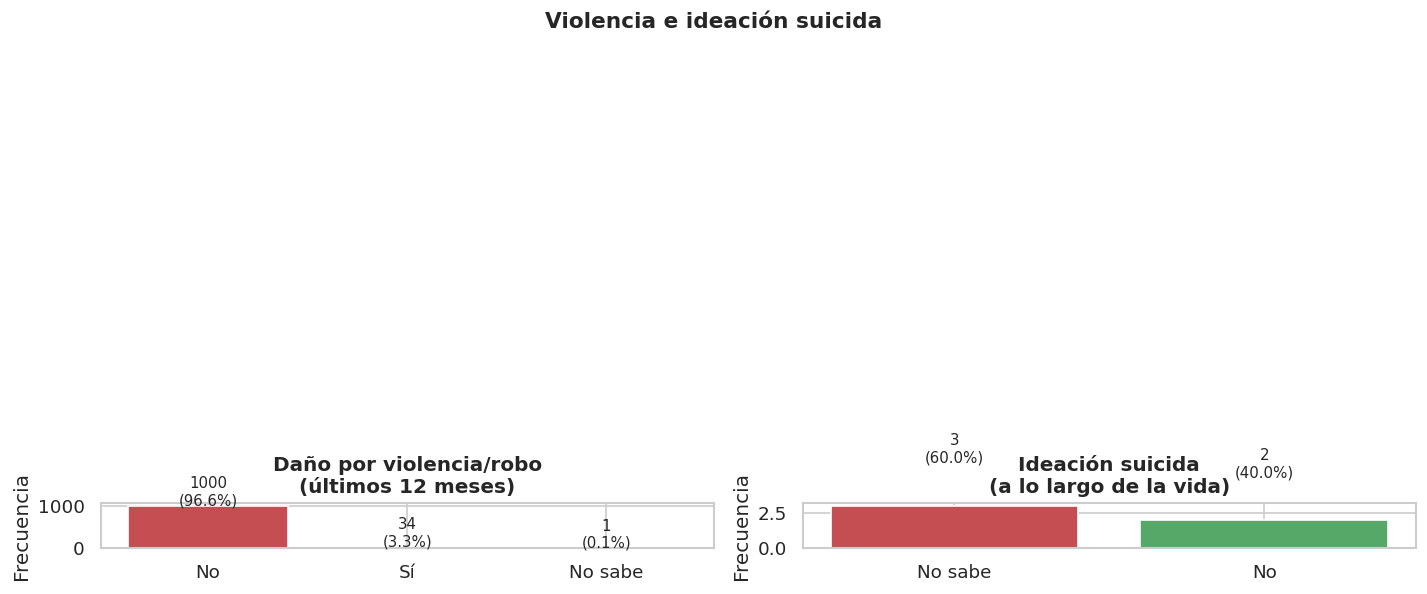

In [30]:
col_viol = 'ADUL201 2.1  En los últimos 12 meses ¿Sufrió usted algún daño a su salud por robo, agresión o violencia?'
col_suic = 'ADUL208 2.8 ¿Alguna vez ha pensado en suicidarse?'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Violencia e ideación suicida', fontsize=13, fontweight='bold')

for ax, (col, title, lmap) in zip(axes, [
    (col_viol, 'Daño por violencia/robo\n(últimos 12 meses)', {1:'Sí',2:'No',9:'No sabe'}),
    (col_suic, 'Ideación suicida\n(a lo largo de la vida)', {1:'Sí',2:'No',9:'No sabe'}),
]):
    if col not in df.columns: continue
    counts = df[col].map(lmap).value_counts()
    pcts = counts / counts.sum() * 100
    bars = ax.bar(counts.index, counts.values,
                  color=['#C44E52','#55A868','#8172B2'], edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Frecuencia')
    for bar, val, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2020/eda_violencia_suicidio.png', bbox_inches='tight')
plt.show()

### 3.5 Violencia doméstica durante el confinamiento COVID-19 (mujeres)

Base de análisis: 611 mujeres



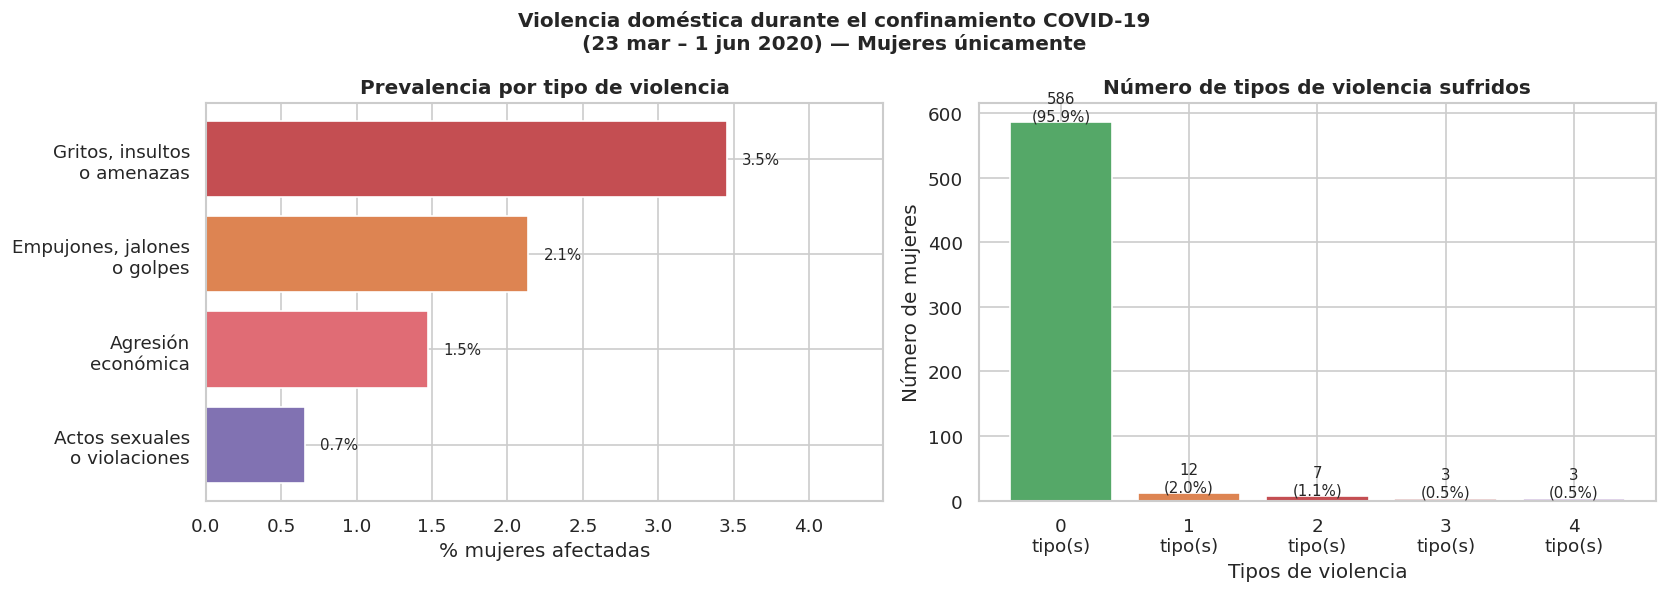

In [31]:
conf_labels = {
    'ADUL301A': 'Gritos, insultos\no amenazas',
    'ADUL301B': 'Empujones, jalones\no golpes',
    'ADUL301C': 'Actos sexuales\no violaciones',
    'ADUL301D': 'Agresión\neconómica',
}
conf_cols_present = {k:v for k,v in conf_labels.items()
                     if any(k in c for c in df.columns)}
conf_col_map = {c: conf_labels[next(k for k in conf_labels if k in c)]
                for c in df.columns if any(k in c for k in conf_labels)}

mujeres = df[df['Sexo'] == 2].copy()
print(f'Base de análisis: {len(mujeres)} mujeres')
print()

# Prevalencia de cada tipo de violencia (solo en mujeres)
prev_conf = {}
for col, label in conf_col_map.items():
    valid = mujeres[col].isin([1, 2])
    prev_conf[label] = (mujeres.loc[valid, col] == 1).mean() * 100

prev_conf_s = pd.Series(prev_conf).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Violencia doméstica durante el confinamiento COVID-19\n(23 mar – 1 jun 2020) — Mujeres únicamente',
             fontsize=12, fontweight='bold')

ax = axes[0]
colors_conf = ['#C44E52','#DD8452','#E06C75','#8172B2']
bars = ax.barh(prev_conf_s.index, prev_conf_s.values, color=colors_conf[::-1], edgecolor='white')
ax.set_title('Prevalencia por tipo de violencia', fontweight='bold')
ax.set_xlabel('% mujeres afectadas')
for bar, val in zip(bars, prev_conf_s.values):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, prev_conf_s.max()*1.3)

ax = axes[1]
if 'Score violencia confinamiento' in df.columns:
    score = df.loc[df['Sexo']==2, 'Score violencia confinamiento'].dropna()
    score_counts = score.value_counts().sort_index()
    score_counts.index = score_counts.index.astype(int).astype(str)
    score_counts.index = [f'{i}\ntipo(s)' for i in score_counts.index]
    ax.bar(score_counts.index, score_counts.values,
           color=['#55A868','#DD8452','#C44E52','#8B0000','#4B0082'], edgecolor='white')
    ax.set_title('Número de tipos de violencia sufridos', fontweight='bold')
    ax.set_xlabel('Tipos de violencia'); ax.set_ylabel('Número de mujeres')
    total = score_counts.sum()
    for i, (xi, v) in enumerate(zip(score_counts.index, score_counts.values)):
        ax.text(i, v+3, f'{v}\n({v/total*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2020/eda_violencia_confinamiento.png', bbox_inches='tight')
plt.show()

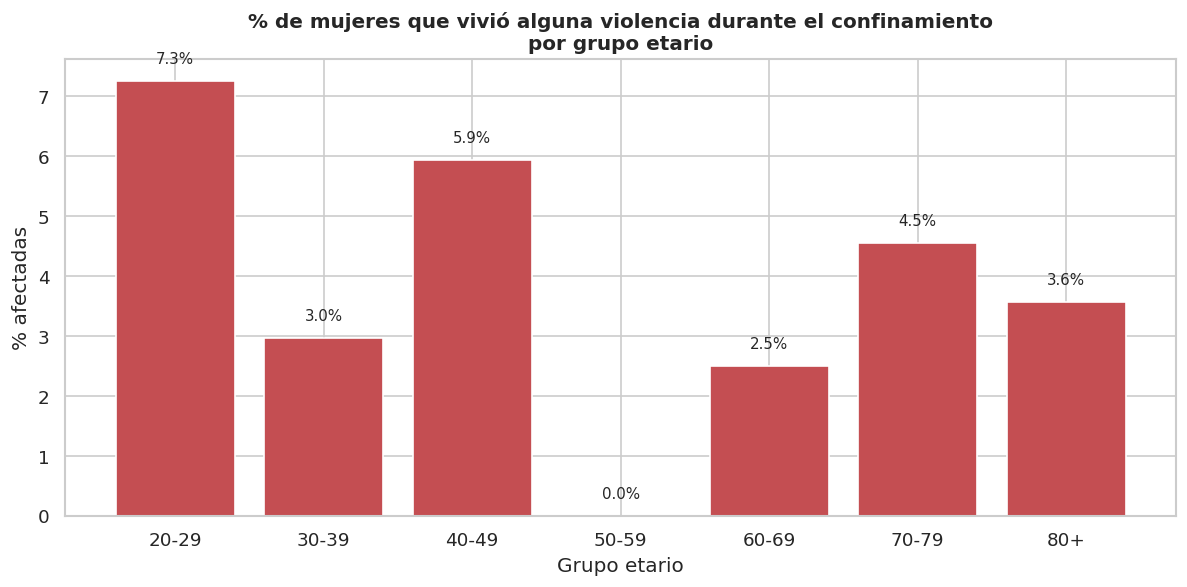

In [32]:
# Violencia confinamiento por grupo etario (mujeres)
if conf_col_map and 'Grupo etario' in df.columns:
    mujeres = df[df['Sexo']==2].copy()
    col_a = [c for c in conf_col_map if 'ADUL301A' in c][0] if any('ADUL301A' in c for c in conf_col_map) else None

    if col_a:
        # % que vivió al menos 1 tipo de violencia
        any_violence = (mujeres[list(conf_col_map.keys())] == 1).any(axis=1)
        mujeres = mujeres.copy()
        mujeres['Alguna violencia'] = any_violence

        pct_by_age = mujeres.groupby('Grupo etario', observed=True)['Alguna violencia'].mean() * 100

        fig, ax = plt.subplots(figsize=(10,5))
        bars = ax.bar(pct_by_age.index.astype(str), pct_by_age.values,
                      color='#C44E52', edgecolor='white')
        ax.set_title('% de mujeres que vivió alguna violencia durante el confinamiento\npor grupo etario',
                     fontweight='bold')
        ax.set_xlabel('Grupo etario'); ax.set_ylabel('% afectadas')
        for bar, val in zip(bars, pct_by_age.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{val:.1f}%', ha='center', fontsize=9)
        plt.tight_layout()
        plt.savefig('../outputs/figures/2020/eda_violencia_edad.png', bbox_inches='tight')
        plt.show()

### 3.6 Cigarros electrónicos

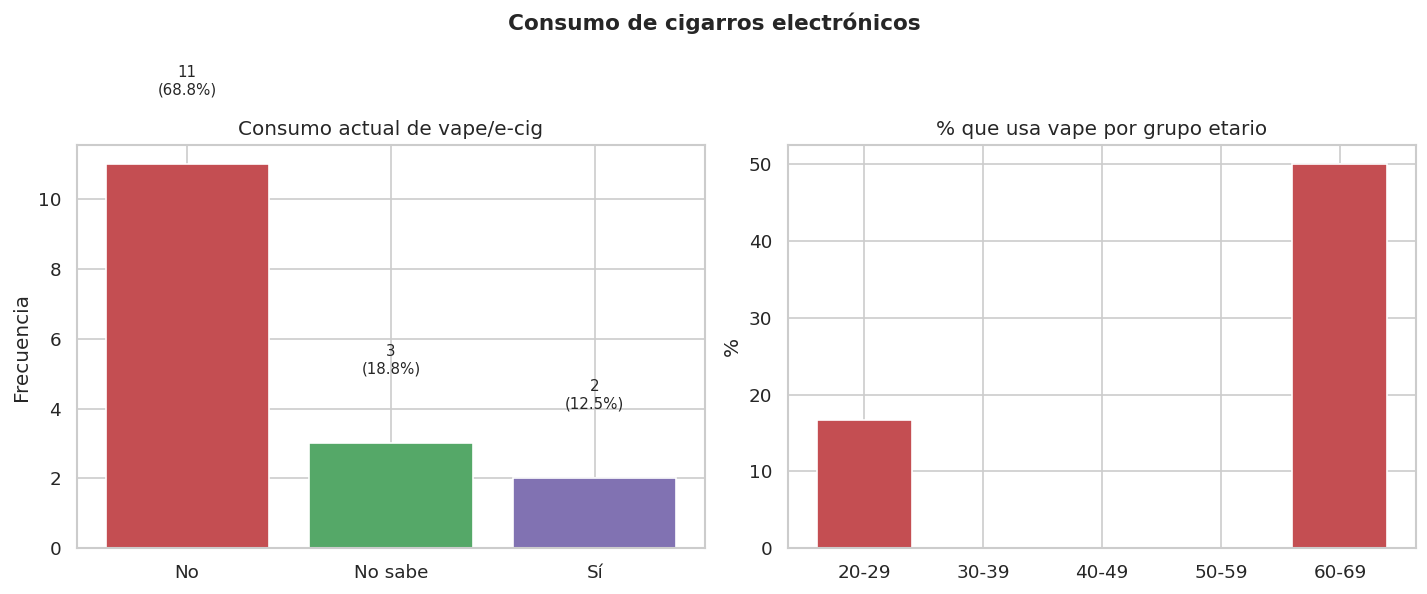

In [33]:
col_vape = 'ADUL1a05 ¿Actualmente consumes cigarros electrónicos ?'
if col_vape in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    fig.suptitle('Consumo de cigarros electrónicos', fontsize=13, fontweight='bold')

    vape_map = {1:'Sí',2:'No',9:'No sabe'}
    counts = df[col_vape].map(vape_map).value_counts()
    pcts = counts/counts.sum()*100
    bars = axes[0].bar(counts.index, counts.values,
                       color=['#C44E52','#55A868','#8172B2'], edgecolor='white')
    axes[0].set_title('Consumo actual de vape/e-cig'); axes[0].set_ylabel('Frecuencia')
    for bar, val, pct in zip(bars, counts.values, pcts.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                     f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)

    # By age group
    df['Usa vape'] = df[col_vape].map({1:'Sí',2:'No',9:'No sabe'})
    pct_vape = (df[df['Usa vape']!='No sabe']
                .groupby(['Grupo etario','Usa vape'], observed=True)
                .size().unstack(fill_value=0))
    pct_vape = pct_vape.div(pct_vape.sum(axis=1), axis=0)*100
    if 'Sí' in pct_vape.columns:
        axes[1].bar(pct_vape.index.astype(str), pct_vape['Sí'],
                    color='#C44E52', edgecolor='white')
        axes[1].set_title('% que usa vape por grupo etario'); axes[1].set_xlabel(''); axes[1].set_ylabel('%')
    plt.tight_layout()
    plt.savefig('../outputs/figures/2020/eda_vape.png', bbox_inches='tight')
    plt.show()

---
## 4. Resumen ejecutivo

In [34]:
print('=' * 65)
print('RESUMEN — ENSANUT COVID-19 2020 Guanajuato')
print('=' * 65)
print(f'  Total de encuestados:    {len(df):,}')
print(f'  Variables de análisis:   {len(df.columns)}')
print(f'  Edad promedio:           {df["Edad"].mean():.1f} años')
print(f'  Mujeres: {(df["Sexo_lbl"]=="Mujer").sum():,} ({(df["Sexo_lbl"]=="Mujer").mean()*100:.1f}%)')
print(f'  Hombres: {(df["Sexo_lbl"]=="Hombre").sum():,} ({(df["Sexo_lbl"]=="Hombre").mean()*100:.1f}%)')
print()

col_c = 'ADUL103 3.  Aceptaría aplicarse la vacuna contra COVID en el momento en el que esté disponible?'
if col_c in df.columns:
    acepta = (df[col_c]==1).mean()*100
    rechaza = (df[col_c]==2).mean()*100
    print(f'  Aceptaría vacuna COVID:  {acepta:.1f}%')
    print(f'  Rechazaría vacuna COVID: {rechaza:.1f}%')

col_tab = 'ADUL1a01 Actualmente fuma tabaco...'
if col_tab in df.columns:
    fuma = df[col_tab].isin([1,2]).mean()*100
    print(f'  Fumadores actuales:      {fuma:.1f}%')

if 'Score violencia confinamiento' in df.columns:
    muj = df[df['Sexo']==2]
    alguna = (muj['Score violencia confinamiento'] >= 1).mean()*100
    print(f'  Mujeres con alguna violencia en confinamiento: {alguna:.1f}%')

col_s = 'ADUL208 2.8 ¿Alguna vez ha pensado en suicidarse?'
if col_s in df.columns:
    valid = df[col_s].isin([1,2]).sum()
    ideacion = (df[col_s]==1).sum() / valid * 100
    print(f'  Ideación suicida (alguna vez): {ideacion:.1f}%')

print('=' * 65)

RESUMEN — ENSANUT COVID-19 2020 Guanajuato
  Total de encuestados:    1,035
  Variables de análisis:   31
  Edad promedio:           45.8 años
  Mujeres: 611 (59.0%)
  Hombres: 424 (41.0%)

  Aceptaría vacuna COVID:  67.8%
  Rechazaría vacuna COVID: 21.0%
  Fumadores actuales:      15.5%
  Mujeres con alguna violencia en confinamiento: 4.1%
  Ideación suicida (alguna vez): 0.0%
